Tubes Big Data

Setup, Load Data, dan Data Cleaning Spesifik

In [ ]:
# =====================================================================
# 1. INSTALASI LIBRARY
# =====================================================================
!pip install pyspark
!pip install -q kaggle

import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType

# =====================================================================
# 2. SETUP KAGGLE API (SISTEM BARU) & DOWNLOAD DATASET
# =====================================================================
# Memasukkan token terbaru dari Kaggle
os.environ['KAGGLE_API_TOKEN'] = "KGAT_d41e964adb105b0ecdf3385d309c04c0"

# Mengunduh HANYA file Ebook (3.22 GB)
print("Mengunduh file TSV Ebook spesifik dari Kaggle...")
!kaggle datasets download -d cynthiarempel/amazon-us-customer-reviews-dataset -f amazon_reviews_us_Digital_Ebook_Purchase_v1_01.tsv

# Mengekstrak file zip yang terunduh
print("Mengekstrak file TSV...")
!unzip -o amazon_reviews_us_Digital_Ebook_Purchase_v1_01.tsv.zip
print("Download & Ekstrak Selesai!\n")

# =====================================================================
# 3. INISIALISASI SPARK & MEMUAT DATASET
# =====================================================================
# Inisialisasi Spark dengan memori yang dioptimalkan
spark = SparkSession.builder \
    .appName("AmazonEbookBigDataAI") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

# Memuat Dataset TSV langsung dari penyimpanan lokal Colab
file_path = 'amazon_reviews_us_Digital_Ebook_Purchase_v1_01.tsv'
df = spark.read.csv(file_path, header=True, sep='\t', inferSchema=True)

# =====================================================================
# 4. VERIFIKASI DATA & DATA CLEANING AWAL
# =====================================================================
print("Menampilkan 5 sampel data mentah pertama:")
df.show(5, truncate=True)

# Hapus baris yang teks ulasan atau ratingnya kosong
df_clean = df.dropna(subset=["review_body", "star_rating", "verified_purchase", "helpful_votes"])

# Pastikan tipe data benar
df_clean = df_clean.withColumn("star_rating", F.col("star_rating").cast(IntegerType())) \
                   .withColumn("helpful_votes", F.col("helpful_votes").cast(IntegerType()))

# Filter rating 3 (netral) dan buat label biner (1 = Positif, 0 = Negatif)
df_filtered = df_clean.filter(F.col("star_rating") != 3)
df_labeled = df_filtered.withColumn("label", F.when(F.col("star_rating") > 3, 1).otherwise(0))

print("\nData siap diproses ke pipeline NLP!")

Mengunduh file TSV Ebook spesifik dari Kaggle...
Dataset URL: https://www.kaggle.com/datasets/cynthiarempel/amazon-us-customer-reviews-dataset
License(s): other
100% 1.22G/1.22G [00:17<00:00, 73.7MB/s]

Mengekstrak file TSV...
Archive:  amazon_reviews_us_Digital_Ebook_Purchase_v1_01.tsv.zip
  inflating: amazon_reviews_us_Digital_Ebook_Purchase_v1_01.tsv  
Download & Ekstrak Selesai!

Menampilkan 5 sampel data mentah pertama:
+-----------+-----------+--------------+----------+--------------+--------------------+--------------------+-----------+-------------+-----------+----+-----------------+--------------------+--------------------+-----------+
|marketplace|customer_id|     review_id|product_id|product_parent|       product_title|    product_category|star_rating|helpful_votes|total_votes|vine|verified_purchase|     review_headline|         review_body|review_date|
+-----------+-----------+--------------+----------+--------------+--------------------+--------------------+-----------+---

In [ ]:
print("Menampilkan 5 sampel data setelah dilabeli:")
df_labeled.select("star_rating", "label", "review_body").show(5, truncate=True)

Menampilkan 5 sampel data setelah dilabeli:
+-----------+-----+--------------------+
|star_rating|label|         review_body|
+-----------+-----+--------------------+
|          4|    1|Elmore Leonard me...|
|          4|    1|This book was ver...|
|          5|    1|I had the opportu...|
|          5|    1|What a great read...|
|          5|    1|Barbarians need l...|
+-----------+-----+--------------------+
only showing top 5 rows


In [ ]:
# ngelompokin user dengan rating (4-5) dengan label 1 dan rating 2-1 dengan label 0
df_labeled.groupBy("label").count().show()

+-----+-------+
|label|  count|
+-----+-------+
|    1|4129646|
|    0| 490004|
+-----+-------+



Pipeline AI (Feature Engineering & Training)

In [ ]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

# 1. Komponen NLP
tokenizer = Tokenizer(inputCol="review_body", outputCol="words")
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
hashingTF = HashingTF(inputCol="filtered_words", outputCol="rawFeatures", numFeatures=10000)
idf = IDF(inputCol="rawFeatures", outputCol="features")

# 2. Model AI
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=10, regParam=0.1)

# 3. Merangkai Pipeline
pipeline = Pipeline(stages=[tokenizer, remover, hashingTF, idf, lr])

# 4. Split Data (80% Train, 20% Test)
train_data, test_data = df_labeled.randomSplit([0.8, 0.2], seed=42)

# 5. Training Model AI
print("Sedang melatih model AI... (Proses ini mungkin memakan waktu beberapa menit)")
model = pipeline.fit(train_data)
print("Training Model Selesai!")

Sedang melatih model AI... (Proses ini mungkin memakan waktu beberapa menit)
Training Model Selesai!


Evaluasi Model AI

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

# Lakukan prediksi pada data testing
predictions = model.transform(test_data)

# =====================================================================
# 1. Evaluasi AUC-ROC (Kemampuan membedakan kelas)
# =====================================================================
eval_auc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
auc = eval_auc.evaluate(predictions)

# =====================================================================
# 2. Evaluasi Akurasi, F1-Score, Precision, dan Recall
# =====================================================================
eval_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = eval_acc.evaluate(predictions)

eval_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
f1_score = eval_f1.evaluate(predictions)

eval_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
precision = eval_precision.evaluate(predictions)

eval_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
recall = eval_recall.evaluate(predictions)

# =====================================================================
# 3. Menampilkan Hasil
# =====================================================================
print(f"Area Under ROC (AUC) : {auc:.4f}")
print(f"Akurasi Model        : {accuracy * 100:.2f}%")
print(f"F1-Score             : {f1_score:.4f}")
print(f"Weighted Precision   : {precision:.4f}")
print(f"Weighted Recall      : {recall:.4f}")

Area Under ROC (AUC) : 0.9462
Akurasi Model        : 91.88%
F1-Score             : 0.8984
Weighted Precision   : 0.9168
Weighted Recall      : 0.9188


Analisis Perilaku Pelanggan

Mengagregasi data Verified Purchase...


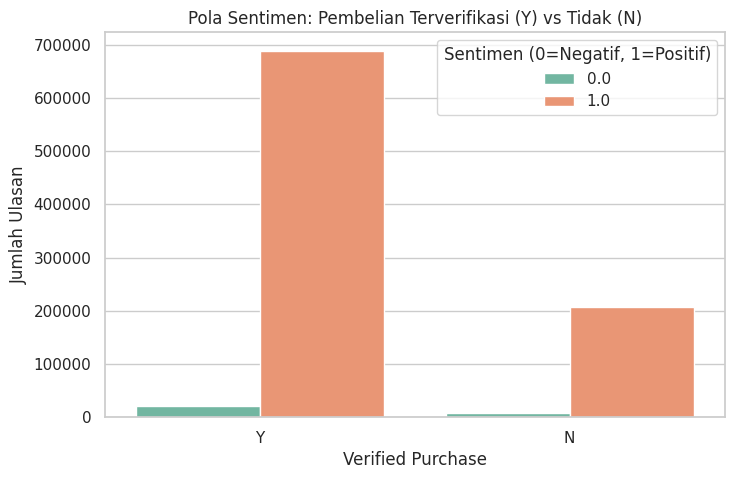


Mengagregasi rata-rata Helpful Votes berdasarkan Sentimen...


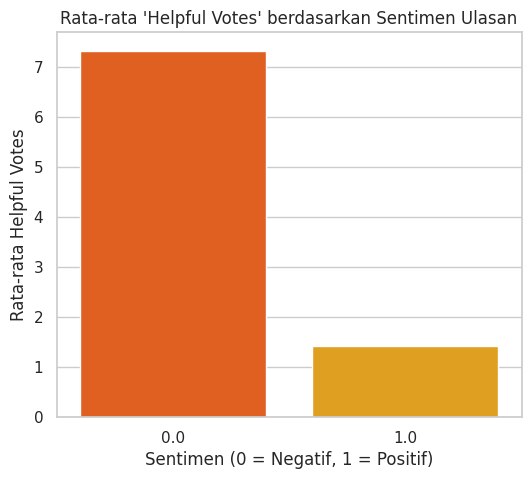

DataFrame[marketplace: string, customer_id: int, review_id: string, product_id: string, product_parent: int, product_title: string, product_category: string, star_rating: int, helpful_votes: int, total_votes: int, vine: string, verified_purchase: string, review_headline: string, review_body: string, review_date: date, label: int, words: array<string>, filtered_words: array<string>, rawFeatures: vector, features: vector, rawPrediction: vector, probability: vector, prediction: double]

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Agar grafik terlihat bagus
sns.set_theme(style="whitegrid")

# OPTIMASI: Cache dataframe predictions agar tidak dihitung ulang oleh Spark
# saat melakukan dua kali operasi agregasi di bawah.
predictions.cache()

# =================================================================
# INSIGHT 1: Perilaku Sentimen berdasarkan 'Verified Purchase'
# Apakah pelanggan yang tidak terverifikasi lebih sering memberi review negatif/palsu?
# =================================================================
print("Mengagregasi data Verified Purchase...")
verified_behavior = predictions.groupBy("verified_purchase", "prediction").count().toPandas()

# Visualisasi Insight 1
plt.figure(figsize=(8, 5))
sns.barplot(data=verified_behavior, x="verified_purchase", y="count", hue="prediction", palette="Set2")
plt.title("Pola Sentimen: Pembelian Terverifikasi (Y) vs Tidak (N)")
plt.xlabel("Verified Purchase")
plt.ylabel("Jumlah Ulasan")
plt.legend(title='Sentimen (0=Negatif, 1=Positif)')
plt.show()

# =================================================================
# INSIGHT 2: Dampak Sentimen terhadap 'Helpful Votes'
# Apakah ulasan negatif dianggap lebih "membantu" oleh pelanggan lain?
# =================================================================
print("\nMengagregasi rata-rata Helpful Votes berdasarkan Sentimen...")
helpful_behavior = predictions.groupBy("prediction").agg(F.avg("helpful_votes").alias("avg_helpful_votes")).toPandas()

# Visualisasi Insight 2
plt.figure(figsize=(6, 5))
# Menambahkan hue="prediction" dan legend=False untuk mengatasi FutureWarning
sns.barplot(data=helpful_behavior, x="prediction", y="avg_helpful_votes", hue="prediction", palette="autumn", legend=False)
plt.title("Rata-rata 'Helpful Votes' berdasarkan Sentimen Ulasan")
plt.xlabel("Sentimen (0 = Negatif, 1 = Positif)")
plt.ylabel("Rata-rata Helpful Votes")
plt.show()

# Kosongkan cache setelah selesai untuk membebaskan memori
predictions.unpersist()

Menghitung panjang teks ulasan...


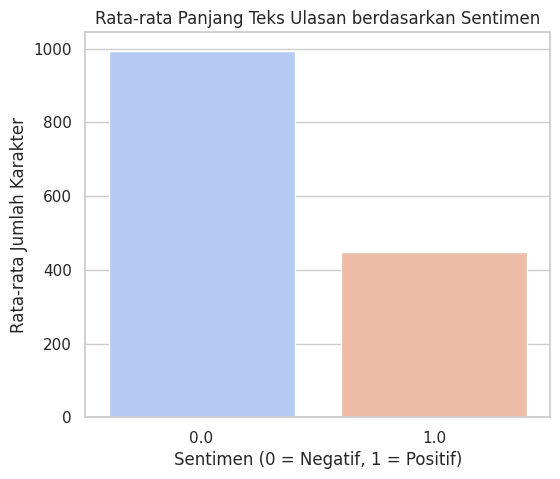

In [ ]:
# =================================================================
# INSIGHT 3: Rata-rata Panjang Ulasan vs Sentimen
# Korelasi Panjang Teks Ulasan dengan Sentimen (Apakah Pelanggan yang Kecewa Menulis Lebih Panjang?)
# =================================================================
print("Menghitung panjang teks ulasan...")
# Membuat kolom baru berisi panjang string dari review_body
predictions = predictions.withColumn("review_length", F.length(F.col("review_body")))

# Agregasi rata-rata panjang teks berdasarkan prediksi sentimen
length_behavior = predictions.groupBy("prediction").agg(F.avg("review_length").alias("avg_length")).toPandas()

# Visualisasi Insight 3
plt.figure(figsize=(6, 5))
sns.barplot(data=length_behavior, x="prediction", y="avg_length", hue="prediction", palette="coolwarm", legend=False)
plt.title("Rata-rata Panjang Teks Ulasan berdasarkan Sentimen")
plt.xlabel("Sentimen (0 = Negatif, 1 = Positif)")
plt.ylabel("Rata-rata Jumlah Karakter")
plt.show()

Mengambil data distribusi rating bintang...


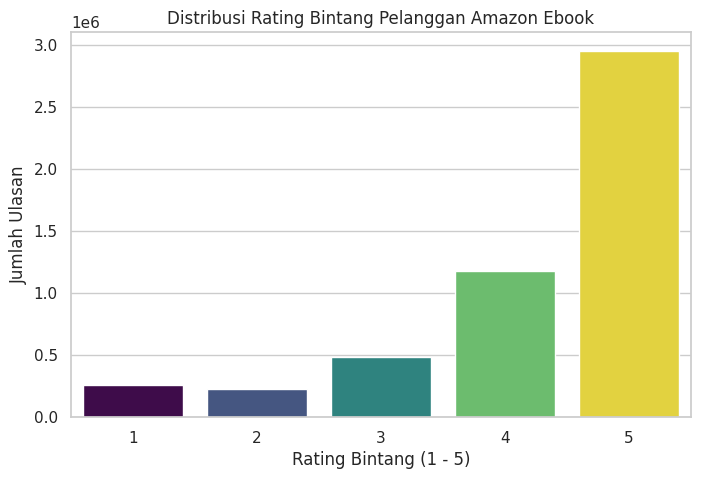

In [ ]:
# =================================================================
# INSIGHT 4: Distribusi Rating Bintang Asli (1 - 5) alias pake data asli dari dataset
# =================================================================
print("Mengambil data distribusi rating bintang...")
# Menggunakan df_clean agar bintang 3 tetap ikut terhitung dalam grafik
rating_dist = df_clean.groupBy("star_rating").count().orderBy("star_rating").toPandas()

# Visualisasi Insight 4
plt.figure(figsize=(8, 5))
sns.barplot(data=rating_dist, x="star_rating", y="count", hue="star_rating", palette="viridis", legend=False)
plt.title("Distribusi Rating Bintang Pelanggan Amazon Ebook")
plt.xlabel("Rating Bintang (1 - 5)")
plt.ylabel("Jumlah Ulasan")
plt.show()